数据集加载成功: (249800, 2500)


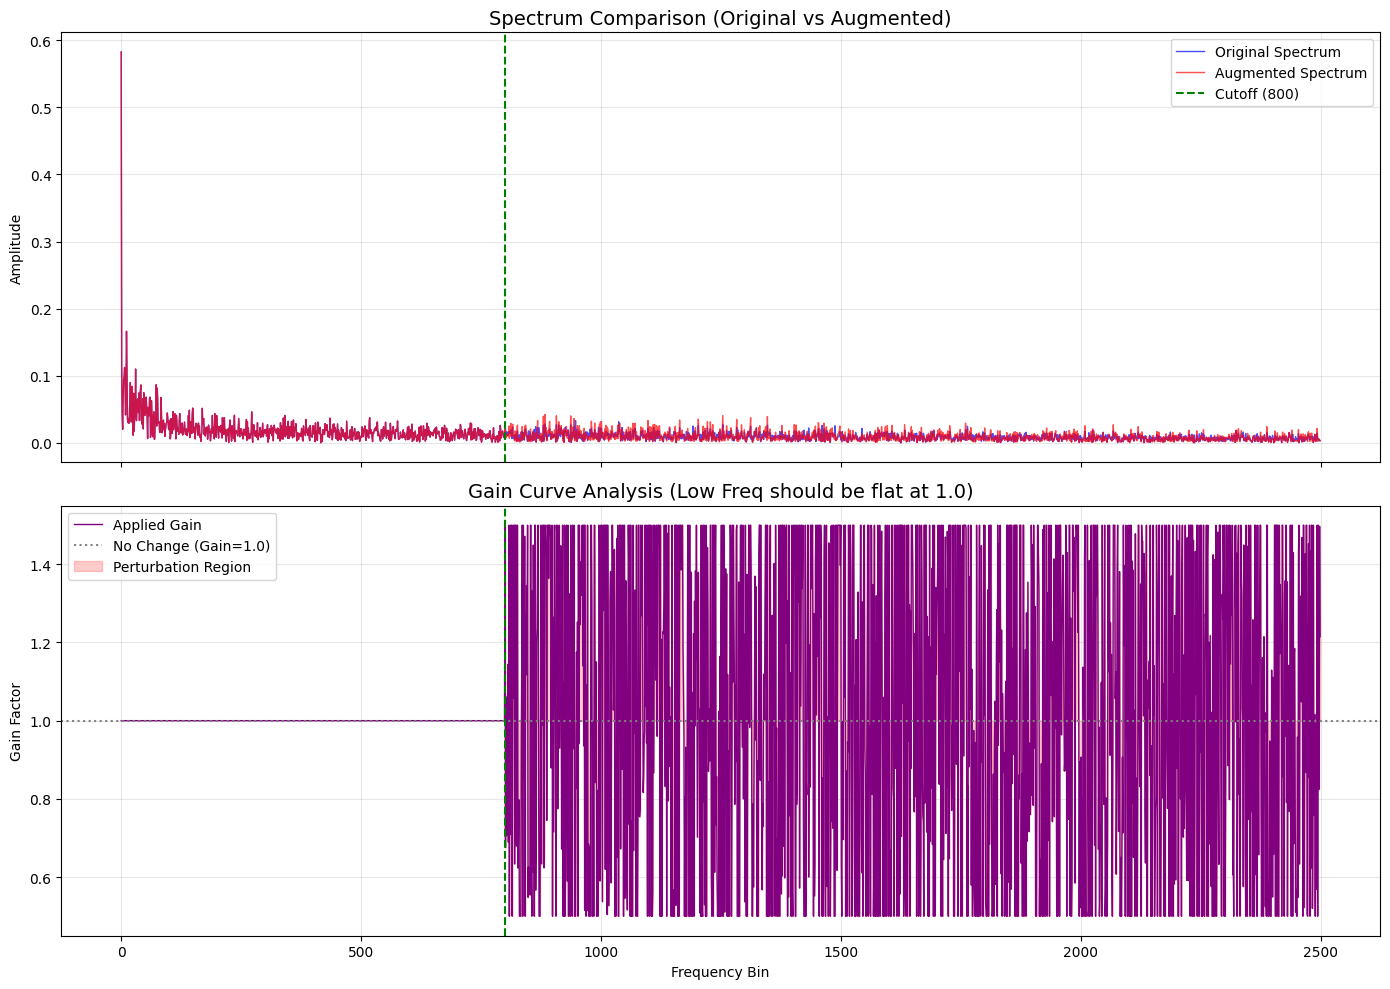

In [2]:
import numpy as np
from scipy.ndimage import uniform_filter1d  # 用于平滑
import matplotlib.pyplot as plt 

class FreqAugTool:
    def freq_augment_spectrum(
            self,
            spec: np.ndarray,
            low_cutoff: int = 800,
            rho: float = 1.0,      # 建议降低默认值
            alpha: float = 3.0,
            beta: float = 2.0,
            gamma: float = 1.0,    # 建议降低默认值，线性化响应
            eps: float = 1e-6,
            seed: int = None,
            smooth_window: int = 50, # 新增：平滑窗口大小
            max_gain: float = 1.5,   # 新增：最大增益限制
            min_gain: float = 0.5    # 新增：最小增益限制
    ):
        if seed is not None:
            np.random.seed(seed)

        G = spec.copy()
        N = len(G)

        # 1. 全局统计量
        global_mu = np.mean(G)
        global_sigma = np.std(G)

        # 2. 掩码逻辑 (保持原样)
        M_suppress = np.ones_like(G)
        M_suppress[low_cutoff:] = 0.0
        G_M = (1 - M_suppress) * G

        # 3. 映射函数
        numerator = np.square(G_M - alpha * global_mu)
        denominator = 2 * np.square(beta * global_sigma)
        denominator = np.maximum(denominator, eps)

        exp_term = np.exp(- numerator / denominator)
        G_H = np.power(rho * exp_term, gamma) + eps

        # --- 关键修改点 1: 平滑 noise_scale ---
        # 在应用随机噪声前，先让标准差曲线变平滑，避免相邻频率点扰动差异过大
        # 仅对中高频部分进行平滑
        noise_scale = G_H.copy()
        if smooth_window > 1:
            # 对整体做平滑，或者只对 high_freq 部分做
            # 这里简单处理：对整个 noise_scale 做滑动平均
            noise_scale = uniform_filter1d(noise_scale, size=smooth_window)

        # 强制低频部分无扰动
        noise_scale[:low_cutoff] = 0.0

        # 4. 生成增益
        gain = np.random.normal(loc=1.0, scale=noise_scale, size=N)

        # --- 关键修改点 2: 限制增益范围 (Clipping) ---
        # 防止出现 5倍、10倍 这种破坏性的极端值
        gain = np.clip(gain, a_min=min_gain, a_max=max_gain)

        aug_spec = G * gain

        return aug_spec, gain

def visualize_augmentation(original_spec, augmented_spec, gain_curve, cutoff):
    """可视化增强效果"""
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
    
    # 上图：频谱对比
    ax1.plot(original_spec, label='Original Spectrum', color='blue', alpha=0.7, linewidth=1)
    ax1.plot(augmented_spec, label='Augmented Spectrum', color='red', alpha=0.7, linewidth=1)
    ax1.axvline(x=cutoff, color='green', linestyle='--', label=f'Cutoff ({cutoff})')
    ax1.set_title('Spectrum Comparison (Original vs Augmented)', fontsize=14)
    ax1.set_ylabel('Amplitude')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 下图：增益曲线 (这是理解扰动的关键)
    ax2.plot(gain_curve, color='purple', label='Applied Gain', linewidth=1)
    ax2.axhline(y=1.0, color='gray', linestyle=':', label='No Change (Gain=1.0)')
    ax2.axvline(x=cutoff, color='green', linestyle='--')
    ax2.fill_between(range(len(gain_curve)), 1.0, gain_curve, 
                     where=(np.arange(len(gain_curve)) >= cutoff), 
                     color='red', alpha=0.2, label='Perturbation Region')
    ax2.set_title('Gain Curve Analysis (Low Freq should be flat at 1.0)', fontsize=14)
    ax2.set_xlabel('Frequency Bin')
    ax2.set_ylabel('Gain Factor')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    # 初始化
    aug_tool = FreqAugTool()
    
    try:
        # 读取数据
        data = np.load("./datasets/awf1_freq.npz")
        x_ori_freq = data["x"]   # shape (N_samples, 2500)
        
        print(f"数据集加载成功: {x_ori_freq.shape}")
        
        # 取第一条样本
        sample_idx = 0
        original_sample = x_ori_freq[sample_idx]
        
        # 执行增强
        # 假设低截止频率为 800 (根据你的数据长度 2500 调整)
        augmented_sample, applied_gain = aug_tool.freq_augment_spectrum(
            spec=original_sample,
            low_cutoff=800, 
            seed=42 # 固定种子以便复现
        )
        
        # 可视化
        visualize_augmentation(original_sample, augmented_sample, applied_gain, cutoff=800)
        
    except FileNotFoundError:
        print("错误: 未找到文件 ./datasets/awf1_freq.npz")
        print("正在生成模拟数据进行演示...")
        
        # --- 模拟数据演示模式 ---
        N = 2500
        freqs = np.linspace(0, 100, N)
        # 模拟一个典型的 1/f 频谱 + 一些峰值
        mock_spec = 1.0 / (freqs + 1) + 0.5 * np.sin(freqs * 0.1)
        mock_spec += np.random.normal(0, 0.05, N) # 加点噪声
        
        aug_spec, gain = aug_tool.freq_augment_spectrum(mock_spec, low_cutoff=800, seed=42)
        visualize_augmentation(mock_spec, aug_spec, gain, cutoff=800)